# 02 — Edit Distance on Real sequences (EDR)

*Reference:* https://dl.acm.org/doi/epdf/10.1145/1066157.1066213

**What it measures.** EDR treats the two series like two *strings* and counts how many
edit operations (insert, delete, substitute) are needed to turn one into the other. Two
samples count as "the same character" when they are within a tolerance `eps`:

```
match(x_i, y_j) = 0  if |x_i - y_j| <= eps
                  1  otherwise
```

**Key idea / formula.** The DP recursion is the classical Levenshtein recursion, with
that thresholded comparison in place of character equality:

```
D[i, j] = min( D[i-1, j-1] + match(x_i, y_j),  # substitute (free if within eps)
               D[i-1, j]   + 1,                # delete x_i
               D[i,   j-1] + 1 )               # insert y_j
```

with `D[i, 0] = i` and `D[0, j] = j`. The result is a *count of edits*, so it is always
an integer between 0 and `max(n, m)`.

**What sets EDR apart from DTW/ERP.** EDR quantizes the value axis: once two samples are
within `eps` the actual difference no longer matters, and beyond `eps` every mismatch
costs the same 1. That makes it robust against outliers and local noise, but it also
means the result depends entirely on the choice of `eps` — the parameter we vary
explicitly below. And because gaps are free of any magnitude penalty, EDR (like DTW,
unlike ERP in notebook 03) violates the triangle inequality and is therefore not a
metric.

In [2]:
import sys
from pathlib import Path

# The notebooks live in `notebooks/`, the packages in the project root.
ROOT = Path.cwd()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data.synthetic import generate_dataset
from utils import plotting

%matplotlib inline
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

In [3]:
# Same shared dataset as in notebook 01 (fixed seed -> identical signals).
dataset = generate_dataset()
reference = dataset["reference"]
variants = [name for name in dataset if name != "reference"]

print("reference: n =", len(reference),
      f"| value range [{reference.min():.2f}, {reference.max():.2f}]"
      f" | std {reference.std():.2f}")

reference: n = 300 | value range [-2.50, 3.45] | std 1.47


In [4]:
def edr_cost_matrix(x: np.ndarray, y: np.ndarray, eps: float) -> np.ndarray:
    """Accumulated EDR cost matrix for two 1-D series.

    Parameters
    ----------
    x, y : np.ndarray
        The two series, of length ``n`` and ``m``.
    eps : float
        Matching tolerance. ``|x_i - y_j| <= eps`` is a free match (cost 0),
        anything else is a substitution (cost 1).

    Returns
    -------
    np.ndarray
        Matrix ``D`` of shape ``(n + 1, m + 1)``. The border is initialised with
        ``D[i, 0] = i`` and ``D[0, j] = j``: aligning a prefix against nothing
        costs one deletion/insertion per sample.
    """
    n, m = len(x), len(y)
    # Boolean "are these two samples equal?" table, computed once.
    match = np.abs(x[:, None] - y[None, :]) <= eps

    D = np.zeros((n + 1, m + 1))
    D[:, 0] = np.arange(n + 1)
    D[0, :] = np.arange(m + 1)
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            sub = 0.0 if match[i - 1, j - 1] else 1.0
            D[i, j] = min(D[i - 1, j - 1] + sub,  # substitute / free match
                          D[i - 1, j] + 1.0,      # delete x_i
                          D[i, j - 1] + 1.0)      # insert y_j
    return D


def edr_distance(x: np.ndarray, y: np.ndarray, eps: float) -> float:
    """EDR distance: the minimum number of edits, in ``[0, max(n, m)]``."""
    return float(edr_cost_matrix(x, y, eps)[-1, -1])

In [5]:
def edr_path(D: np.ndarray) -> list[tuple[int, int]]:
    """Back-track one optimal edit path through an EDR cost matrix.

    Returns
    -------
    list[tuple[int, int]]
        Pairs ``(i, j)`` of 0-based series indices along the alignment. Deletions
        and insertions also appear as pairs (the index that did *not* advance is
        simply repeated), which is what we plot below.
    """
    i, j = D.shape[0] - 1, D.shape[1] - 1
    path = []
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        step = int(np.argmin([D[i - 1, j - 1], D[i - 1, j], D[i, j - 1]]))
        if step == 0:
            i, j = i - 1, j - 1
        elif step == 1:
            i -= 1
        else:
            j -= 1
    return path[::-1]

In [6]:
# Sanity check: identical series need zero edits, and a series compared against
# an empty-ish constant signal needs one edit per sample.
toy = np.array([0.0, 1.0, 2.0, 3.0])
print("edr(toy, toy)          :", edr_distance(toy, toy, eps=0.1))
print("edr(toy, toy + 0.05)   :", edr_distance(toy, toy + 0.05, eps=0.1))  # within eps
print("edr(toy, toy + 10)     :", edr_distance(toy, toy + 10.0, eps=0.1))  # all mismatch

edr(toy, toy)          : 0.0
edr(toy, toy + 0.05)   : 0.0
edr(toy, toy + 10)     : 4.0


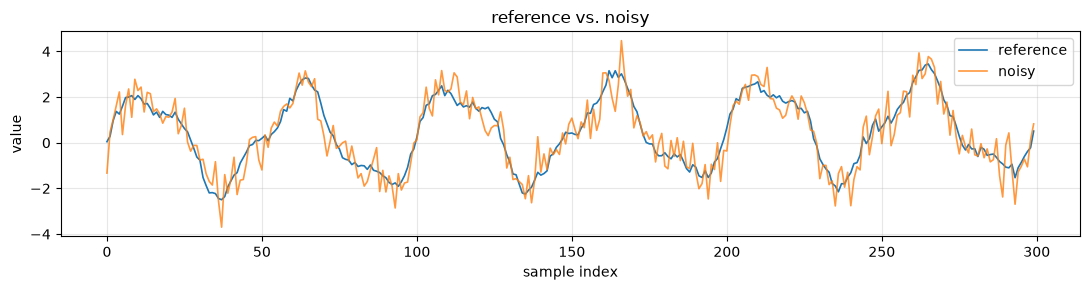

In [7]:
# Visualization part 1: the two signals we align, `reference` and `noisy`.
EPS_DEMO = 0.5
plotting.plot_pair(reference, dataset["noisy"], labels=("reference", "noisy"),
                   title="reference vs. noisy")

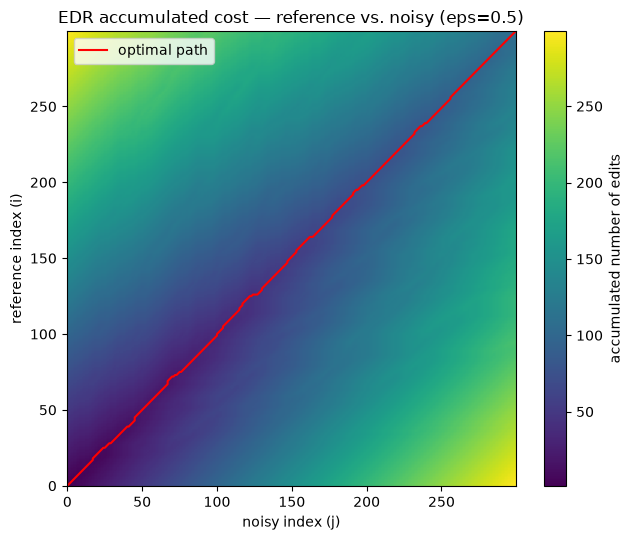

In [ ]:
# Visualization part 2: the DP matrix in the same style as notebook 01.
# The staircase structure comes from the integer costs: whole regions of the
# matrix share the same accumulated number of edits.
D_demo = edr_cost_matrix(reference, dataset["noisy"], eps=EPS_DEMO)
path_demo = edr_path(D_demo)

plotting.plot_cost_matrix(
    D_demo[1:, 1:],
    path=path_demo,
    title=f"EDR accumulated cost — reference vs. noisy (eps={EPS_DEMO})",
    xlabel="noisy index (j)",
    ylabel="reference index (i)",
    cbar_label="accumulated number of edits",
)

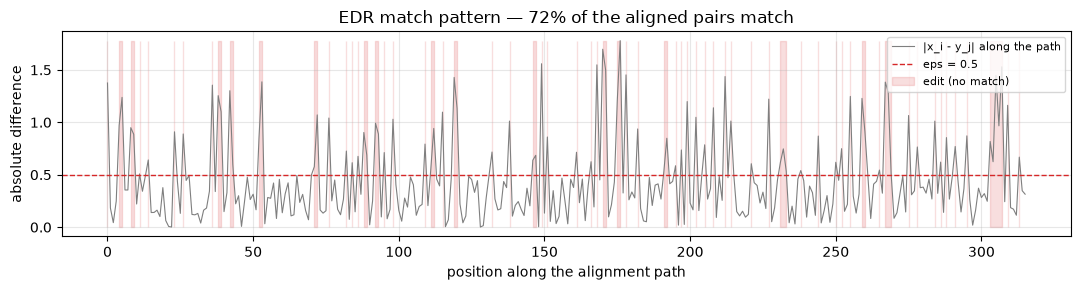

In [9]:
# Visualization part 3: which sample pairs along that optimal path actually
# matched (|x_i - y_j| <= eps) and which had to be paid for as an edit.
pairs = np.array(path_demo)
gap = np.abs(reference[pairs[:, 0]] - dataset["noisy"][pairs[:, 1]])
matched = gap <= EPS_DEMO

plt.figure(figsize=(11, 3))
plt.plot(gap, lw=0.8, color="tab:gray", label="|x_i - y_j| along the path")
plt.axhline(EPS_DEMO, color="tab:red", ls="--", lw=1, label=f"eps = {EPS_DEMO}")
plt.fill_between(np.arange(len(gap)), 0, gap.max(), where=~matched,
                 color="tab:red", alpha=0.15, label="edit (no match)")
plt.title(f"EDR match pattern — {matched.mean():.0%} of the aligned pairs match")
plt.xlabel("position along the alignment path")
plt.ylabel("absolute difference")
plt.legend(loc="upper right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Distance from `reference` to every variant, for several tolerances.
# `eps` is the whole story of EDR, so we vary it over one order of magnitude:
# 0.15 is the noise floor of the reference itself, 1.5 is ~a third of its range.
EPS_VALUES = [0.15, 0.5, 1.5]

edr_table = pd.DataFrame(
    {f"eps={eps}": [edr_distance(reference, dataset[name], eps) for name in variants]
     for eps in EPS_VALUES},
    index=variants,
)
edr_table.index.name = "variant"
edr_table

,eps=0.15,eps=0.5,eps=1.5
variant,,,
amplitude_scaled,263.000,222.000,110.000
resampled,91.000,90.000,90.000
noisy,221.000,107.000,3.000
phase_shifted,80.000,80.000,27.000
reversed,244.000,146.000,52.000
unrelated,282.000,240.000,140.000


In [11]:
# The raw counts are bounded by max(n, m), which differs for `resampled`.
# Normalising by that bound makes the columns comparable: 0 = identical,
# 1 = "no pair of samples ever matched".
bounds = np.array([max(len(reference), len(dataset[name])) for name in variants])
edr_normalized = edr_table.div(bounds, axis=0)
edr_normalized

,eps=0.15,eps=0.5,eps=1.5
variant,,,
amplitude_scaled,0.877,0.740,0.367
resampled,0.233,0.231,0.231
noisy,0.737,0.357,0.010
phase_shifted,0.267,0.267,0.090
reversed,0.813,0.487,0.173
unrelated,0.940,0.800,0.467


## Conclusion

At a sensible tolerance (`eps=0.5`, normalised) the ranking is `resampled` (0.23) and
`phase_shifted` (0.27) as most similar, then `noisy` (0.36) and `reversed` (0.49), with
`amplitude_scaled` (0.74) and `unrelated` (0.80) clearly dissimilar. Like DTW, EDR can
insert and delete samples, so it barely notices a change of sampling rate or a time
offset; unlike DTW, a badly mismatched sample costs 1 no matter how badly it mismatches,
which is why a doubled amplitude — catastrophic for DTW — stays bounded here at 74 % of
the maximum possible edit count.

The `eps` columns show how much rides on that one parameter. At `eps=0.15`, roughly the
noise floor of the reference itself, almost nothing matches any more and every variant
saturates near the maximum (`noisy` alone needs 221 of at most 300 edits). At `eps=1.5`
the same `noisy` series needs **3** edits and is declared all but identical to the
reference. The pair did not change; only the tolerance did. So EDR's robustness to noise
and outliers is real — each bad sample is capped at cost 1 — but the numbers are only
interpretable relative to an `eps` chosen from the noise level of the data, and the
absolute values of two EDR runs with different `eps` must never be compared.